In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/cleaned/model_ready_churn.csv"
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,total_services,avg_monthly_spend,gender_Male,Partner_Yes,Dependents_Yes,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2 Years,tenure_group_2-4 Years,tenure_group_4-5 Years,tenure_group_5-6 Years,monthly_charge_group_Low,monthly_charge_group_Medium,monthly_charge_group_Very High
0,0,1,29.85,29.85,0,1,14.925000,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,0,34,56.95,1889.50,0,3,53.985714,True,False,False,...,False,False,True,False,True,False,False,False,True,False
2,0,2,53.85,108.15,1,3,36.050000,True,False,False,...,False,False,True,False,False,False,False,False,True,False
3,0,45,42.30,1840.75,0,3,40.016304,True,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0,2,70.70,151.65,1,1,50.550000,False,False,False,...,False,True,False,False,False,False,False,False,False,False


**Logistic Regression**

In [2]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7910447761194029


In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[930 103]
 [191 183]]


In [12]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



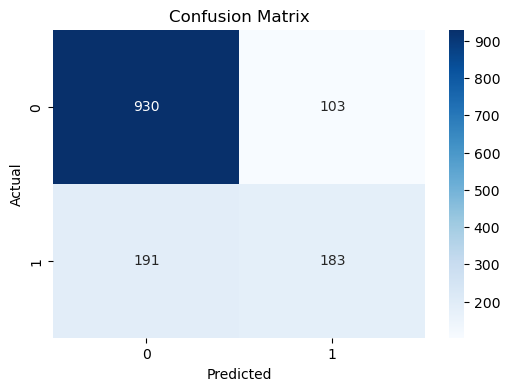

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Decision Tree**

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [16]:
y_pred_dt = dt_model.predict(
    X_test
)

In [17]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(
      y_test,
      y_pred_dt))

Decision Tree Accuracy: 0.7164179104477612
[[818 215]
 [184 190]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1033
           1       0.47      0.51      0.49       374

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407



**Decision Tree (tuned)**

In [18]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree (Tuned) Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(
      y_test,
      y_pred_dt))

Decision Tree (Tuned) Accuracy: 0.775408670931059
[[870 163]
 [153 221]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



**Random Forest model**

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, random_state=42)

In [21]:
y_pred_rf = rf_model.predict(
    X_test
)

In [22]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(
      y_test,
      y_pred_rf))

Random Forest Accuracy: 0.7867803837953091
[[935  98]
 [202 172]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest (Tuned) Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(
      y_test,
      y_pred_rf))

Random Forest (Tuned) Accuracy: 0.7974413646055437
[[939  94]
 [191 183]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



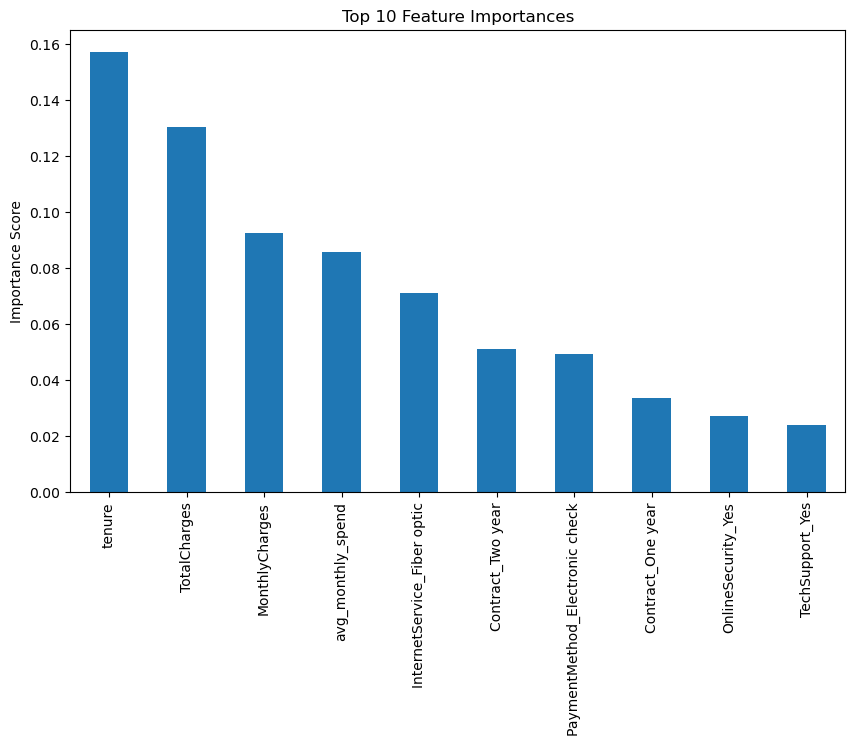

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importances = feature_importances.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

feature_importances.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Feature Importances")

plt.ylabel("Importance Score")

plt.show()

In [25]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.791,
        0.775,
        0.787
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.791
1,Decision Tree,0.775
2,Random Forest,0.787


In [26]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)"
    ],
    "Accuracy": [
        0.791,
        0.775,
        0.797
    ],
    "Recall (Churn)": [
        0.49,
        0.59,
        0.49
    ],
    "Precision (Churn)": [
        0.64,
        0.58,
        0.66
    ]
})

model_results

,Model,Accuracy,Recall (Churn),Precision (Churn)
0,Logistic Regression,0.791,0.49,0.64
1,Decision Tree (Tuned),0.775,0.59,0.58
2,Random Forest (Tuned),0.797,0.49,0.66
